<img src="logo_UNSAM.jpg" align="right" width="150">

#### Análisis y Procesamiento de Señales

# *TS3 - Análisis de Fourier: FFT, desparramo, interpolación y ventaneo*

### *Autora: Catalina Gonzalez Araujo*

### *Docentes: Mariano Llamedo Soria, David Ezequiel Benoit, Francisco Hernan Ledesma.*

# <u>**Resumen**</u>
En este trabajo se estudió el fenómeno de desparramo espectral que se produce al calcular la *DFT* (*Discret Fourir Transform*) de una señal senoidal de potencia normalizada, es decir energía o varianza unitaria. Se consideraron diferentes frecuencias ($f_0 = k_0 \cdot \frac{f_s}{N} = k_0 \cdot \Delta f$) cercanas a múltiplos de la resolución espectral $\Delta f$, variando el indice $k_0$ como $N/4$, $N/4 + 0.25$ y $N/4 + 0.5$. 

En la primera parte, se calculó y graficó, para cada caso, las densidades espectrales de potencia (*PDS*), mostrando cómo una pequeña desintonía respecto a $\Delta f$ provoca una distribución de la energía en varios bins en lugar de concentrarse en uno solo. 

Luego, se verificó mediante la *identidad de Parseval* que la potencia total de cada señal se conserva en el dominio frecuencial, y se discutió por qué dos senoidales con frecuencias muy cercanas pueden producir espectros tan distintos, a pesar de tener la misma energía.

Finalmente, se repitió el experimento aplicando *zero padding*, agregando $9N$ ceros al final de la señal para aumentar $\Delta f$. Se discutieron las ventajas de esta técnica y se analizaron los resultados obtenidos. 

# <u>**Introducción teórica**</u>
La **Transformada Discreta de Fourier (*DFT*)** es una herramienta fundamental en el análisis de señales digitales, ya que permite representar una señal temporal en el dominio de la frecuencia. A nivel computacional, su cálculo se realiza de manera eficiente mediante el algoritmo de la **Transformada Rápida de Fourier** (*FFT*), lo que reduce el costo computacional sin alterar el resultado matemático.

Para comprender la *FFT* se expresa la *DFT* para *N-puntos*: 
$$
X[k] = \sum_{n = 0}^{N - 1} x[n] \cdot e^{-j \cdot \frac{2 \pi}{N} \cdot k \cdot n} = \sum_{n = 0}^{N - 1} x[n] \cdot W_{N}^{k \cdot n} \quad \text{(1)}
$$

donde $W_{N} = e^{-j \cdot \frac{2 \pi}{N}}$.

La *DFT* es una transformación lineal que transforma $x[n]$ en $X[k]$. Podemos pensar a la transformada como una "caja" que toma *N* puntos de $x[n]$ como entrada, y devuelve *N* puntos de $X[k]$ como salida. 

El objetivo de la *FFT* es evaluar a la *DFT* rápido. Para ello, se separa la entrada de la *FFT* en dos subsecuencias de $\frac{N}{2}$ puntos, $x_1[n]$ que representa los valores pares de la entrada, y $x_2[n]$ los impares. Entonces la ecuación *(1)* queda representada como:
$$
X[k] = \sum_{n = 0}^{N - 1} x[n] \cdot W_{N}^{k \cdot n} = \sum_{n = 0}^{N/2 - 1} x[2 \cdot n] \cdot W_{N}^{k \cdot 2 \cdot n} + \sum_{n = 0}^{N/2 - 1} x[2 \cdot n + 1] \cdot W_{N}^{k \cdot (2 \cdot n + 1)} = \sum_{n = 0}^{N/2 - 1} x_1[n] \cdot W_{N}^{k \cdot 2 \cdot n} + \sum_{n = 0}^{N/2 - 1} x_2[n] \cdot W_{N}^{k \cdot (2 \cdot n + 1)} \quad \text{(2)}
$$

Cada sumatoria representa la mitad de la original. Además: $W_{N}^{k \cdot 2 \cdot n} = e^{-j \cdot \frac{2 \pi}{N} \cdot k \cdot 2 \cdot n} = e^{-j \cdot \frac{2 \pi}{N/2} \cdot k \cdot n} = W_{N/2}^{k \cdot n}$ y $W_{N}^{k \cdot (2 \cdot n + 1)} = e^{-j \cdot \frac{2 \pi}{N} \cdot k \cdot (2 \cdot n + 1)} = e^{-j \cdot \frac{2 \cdot \pi}{N} \cdot k \cdot 2 \cdot n} \cdot e^{-j \cdot \frac{2 \cdot \pi}{N} \cdot k} = W_{N/2}^{k \cdot n} \cdot W_{N}^{k}$

Por lo tanto, la ecuación $\quad \text{2}$ resulta en:
$$
X[k] = \sum_{n = 0}^{N/2 - 1} x_1[n] \cdot W_{N/2}^{k \cdot n} + W_{N}^{k} \cdot \sum_{n = 0}^{N/2 - 1} x_2[n] \cdot W_{N/2}^{k \cdot n} = X_1[k] + W_{N}^{k} \cdot X_2[k] \quad 0 \leq k < N
$$

Cada uno de los factores $W_{N}^{k}$ se denominan *twiddle factors*, porque el efecto de multiplicar $X_2[k]$ por un twiddle factor $W_{N}^{k} = e^{-j \cdot \frac {2 \cdot \pi}{N} \cdot k}$ es rotar la fase en $\frac {-2 \cdot \pi \cdot k} {N}$ antes de sumar el resultado de $X_1[k]$.

Las *DFTs* parciales ($X_1[k]$ y $X_2[k]$) son periódicas con período $N/2$, lo cual permite reutilizar los resultados de los primeros $N/2$ valores para obtener los restantes. Entonces, podemos decir que una *DFT* con $N/2$ - puntos, es periódica de período $N/2$. 
$$
X_1[k + N/2] = X_1[k]
X_2[k + N/2] = X_2[k]
$$
con $0 \leq k < N/2$. 

Siendo asi que, cada valor de $N/2$ - puntos de la *DFT* ($X_1[k]$ y $X_2[k]$) es usado dos veces, una para computar $X[k]$ y otra para computar $X[k + N/2]$.

Al trabajar con secuencias finitas, de longitud *N* y discretas, aparecen fenómenos propios de la *DFT* que no ocurren en el análisis continuo.

Uno de estos fenómenos es el **desparramo espectral (spectral leakage)**. Este efecto se produce cuando la frecuencia de la señal no coincide exactamente con un múltiplo entero de la resolución espectral de la *DFT* ($\Delta f = f_s/N$, donde $f_s$ es la frecuencia de muestreo, y $N$ es el número de muestras). En estos casos, la energía de la senoidal no se concentra en un único bin de frecuencia, sino que se distribuye entre varios.

Este desparramo se debe a que la *DFT* asume que la señal es periódica en ventanas de longitud $N$. Si la senoidal no completa un número entero de ciclos dentro de esa ventana, al replicarse aparecen discontinuidades, que se manifiestan en el dominio frecuencial como el ensanchamiento de la energía.

Por otro lado, la **identidad de Parseval** asegura que la potencia total de la señal se conserva entre el dominio temporal y el frecuencial, aunque la forma en que se distribuye en el espectro depende de la sintonía de la frecuencia. En el caso discreto, esta identidad se representa mediante la siguiente ecuación: 
$$
\sum_{n = 0}^{N - 1} |x[n]|^2 = \frac{1}{N} \cdot \sum_{k = 0}^{N - 1}|X[k]|^2
$$

De este modo, aunque la energía se "desparrame" en el espectro, la potencia total se mantiene invariante.

Otra manera de verificar la potencia unitaria de una secuencia es mediante el cálculo de la **varianza**, la cual se define mediante la siguiente ecuación: 
$$
\sigma^2 = \frac{1}{N} \cdot \sum_{n = 0}^{N - 1}(x[n] - \bar{x})^2 
$$
donde $\bar{x}$ es la media de la señal.

Entonces podemos interpretar a la varianza como una medida de la potencia media de la señal. En el caso particular de señales de media cero, la varianza coincide con el valor cuadrático medio (*RMS*), y por lo tanto con la potencia promedio. 

Finalmente, una técnica muy utilizada para mejorar la visualización del espectro es el **zero padding**, que consiste en añadir ceros al final de la señal antes de aplicar la FFT. Esto no incrementa la información frecuencial real ni mejora la resolución espectral efectiva ($\Delta f$), pero sí interpola el espectro, permitiendo observar con mayor detalle la forma de los lóbulos generados por el desparramo espectral.

# <u>**Análisis y desarrollo**</u>

En todos los experimentos realizados se realizaron todos los gráficos en *dB (decibelios)*, lo que significa que en vez de graficar la magnitud lineal de la señal, se la expresa en una escala logarítmica. Esto se hace para mejor visualización del rango dinámico, y para mas facilidad de interpretación. 

Para la implementación en Python se desarrolló una función senoidal específica, a la cual fuimos variando su frecuencia para las distintas experiencias realizadas. Asimismo, se emplearon librerías de *Numpy* para el cálculo de la *FFT*, la verificación de parseval, entre otras. 

En todos los problemas del ejercicio planteado por la cátedra se utilizó la misma longitud de la señal $N = 1000$, y la misma frecuencia de muestreo $f_s = N$. Lo que implica una resolución espectral de $\Delta f = \frac{f_s}{N} = \frac{1}{\text{Hz}}$. 

In [1]:
# Librerias utilizadas
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft

# DEFINO LAS VARIABLES
N = 1000
fs = N
df = fs/N # Resolucion temporal

# DEFINO MI FUNCION SENO
def mi_funcion_sen(frecuencia, nn, amplitud = 1, offset = 0, fase = 0, fs = 2): # Si lo igualo a algo es opcional, entonces si no le paso nada el programa me lo hace cero
     # Los obligatorios van al principio del parentesis y los opcionales al final    

    Ts = 1/fs # Es el tiempo en el cual se toma cada muestra

    tt = np.arange(start = 0, stop= nn*Ts, step = Ts)

    xx = amplitud * np.sin(2 * np.pi * frecuencia * tt + fase) + offset

    return tt, xx

A continuación, se detallan los procedimientos realizados para cumplir con las consignas propuestas por la cátedra, junto con un análisis de cada resultado obtenido.

a) <font color=red><u> **Efecto de la desintonía en el espectro</u><font>**

En esta experiencia se generaron tres senoidales de longitud $N = 1000$ y frecuencia de muestreo $f_s = N$. 

Se consideraron distintas frecuencias, estas fueron: 
$$
f_0 = \frac{N}{4}
$$
$$
f_0 = \frac{N}{4} + 0.25
$$
$$
f_0 = \frac{N}{4} + 0.5
$$

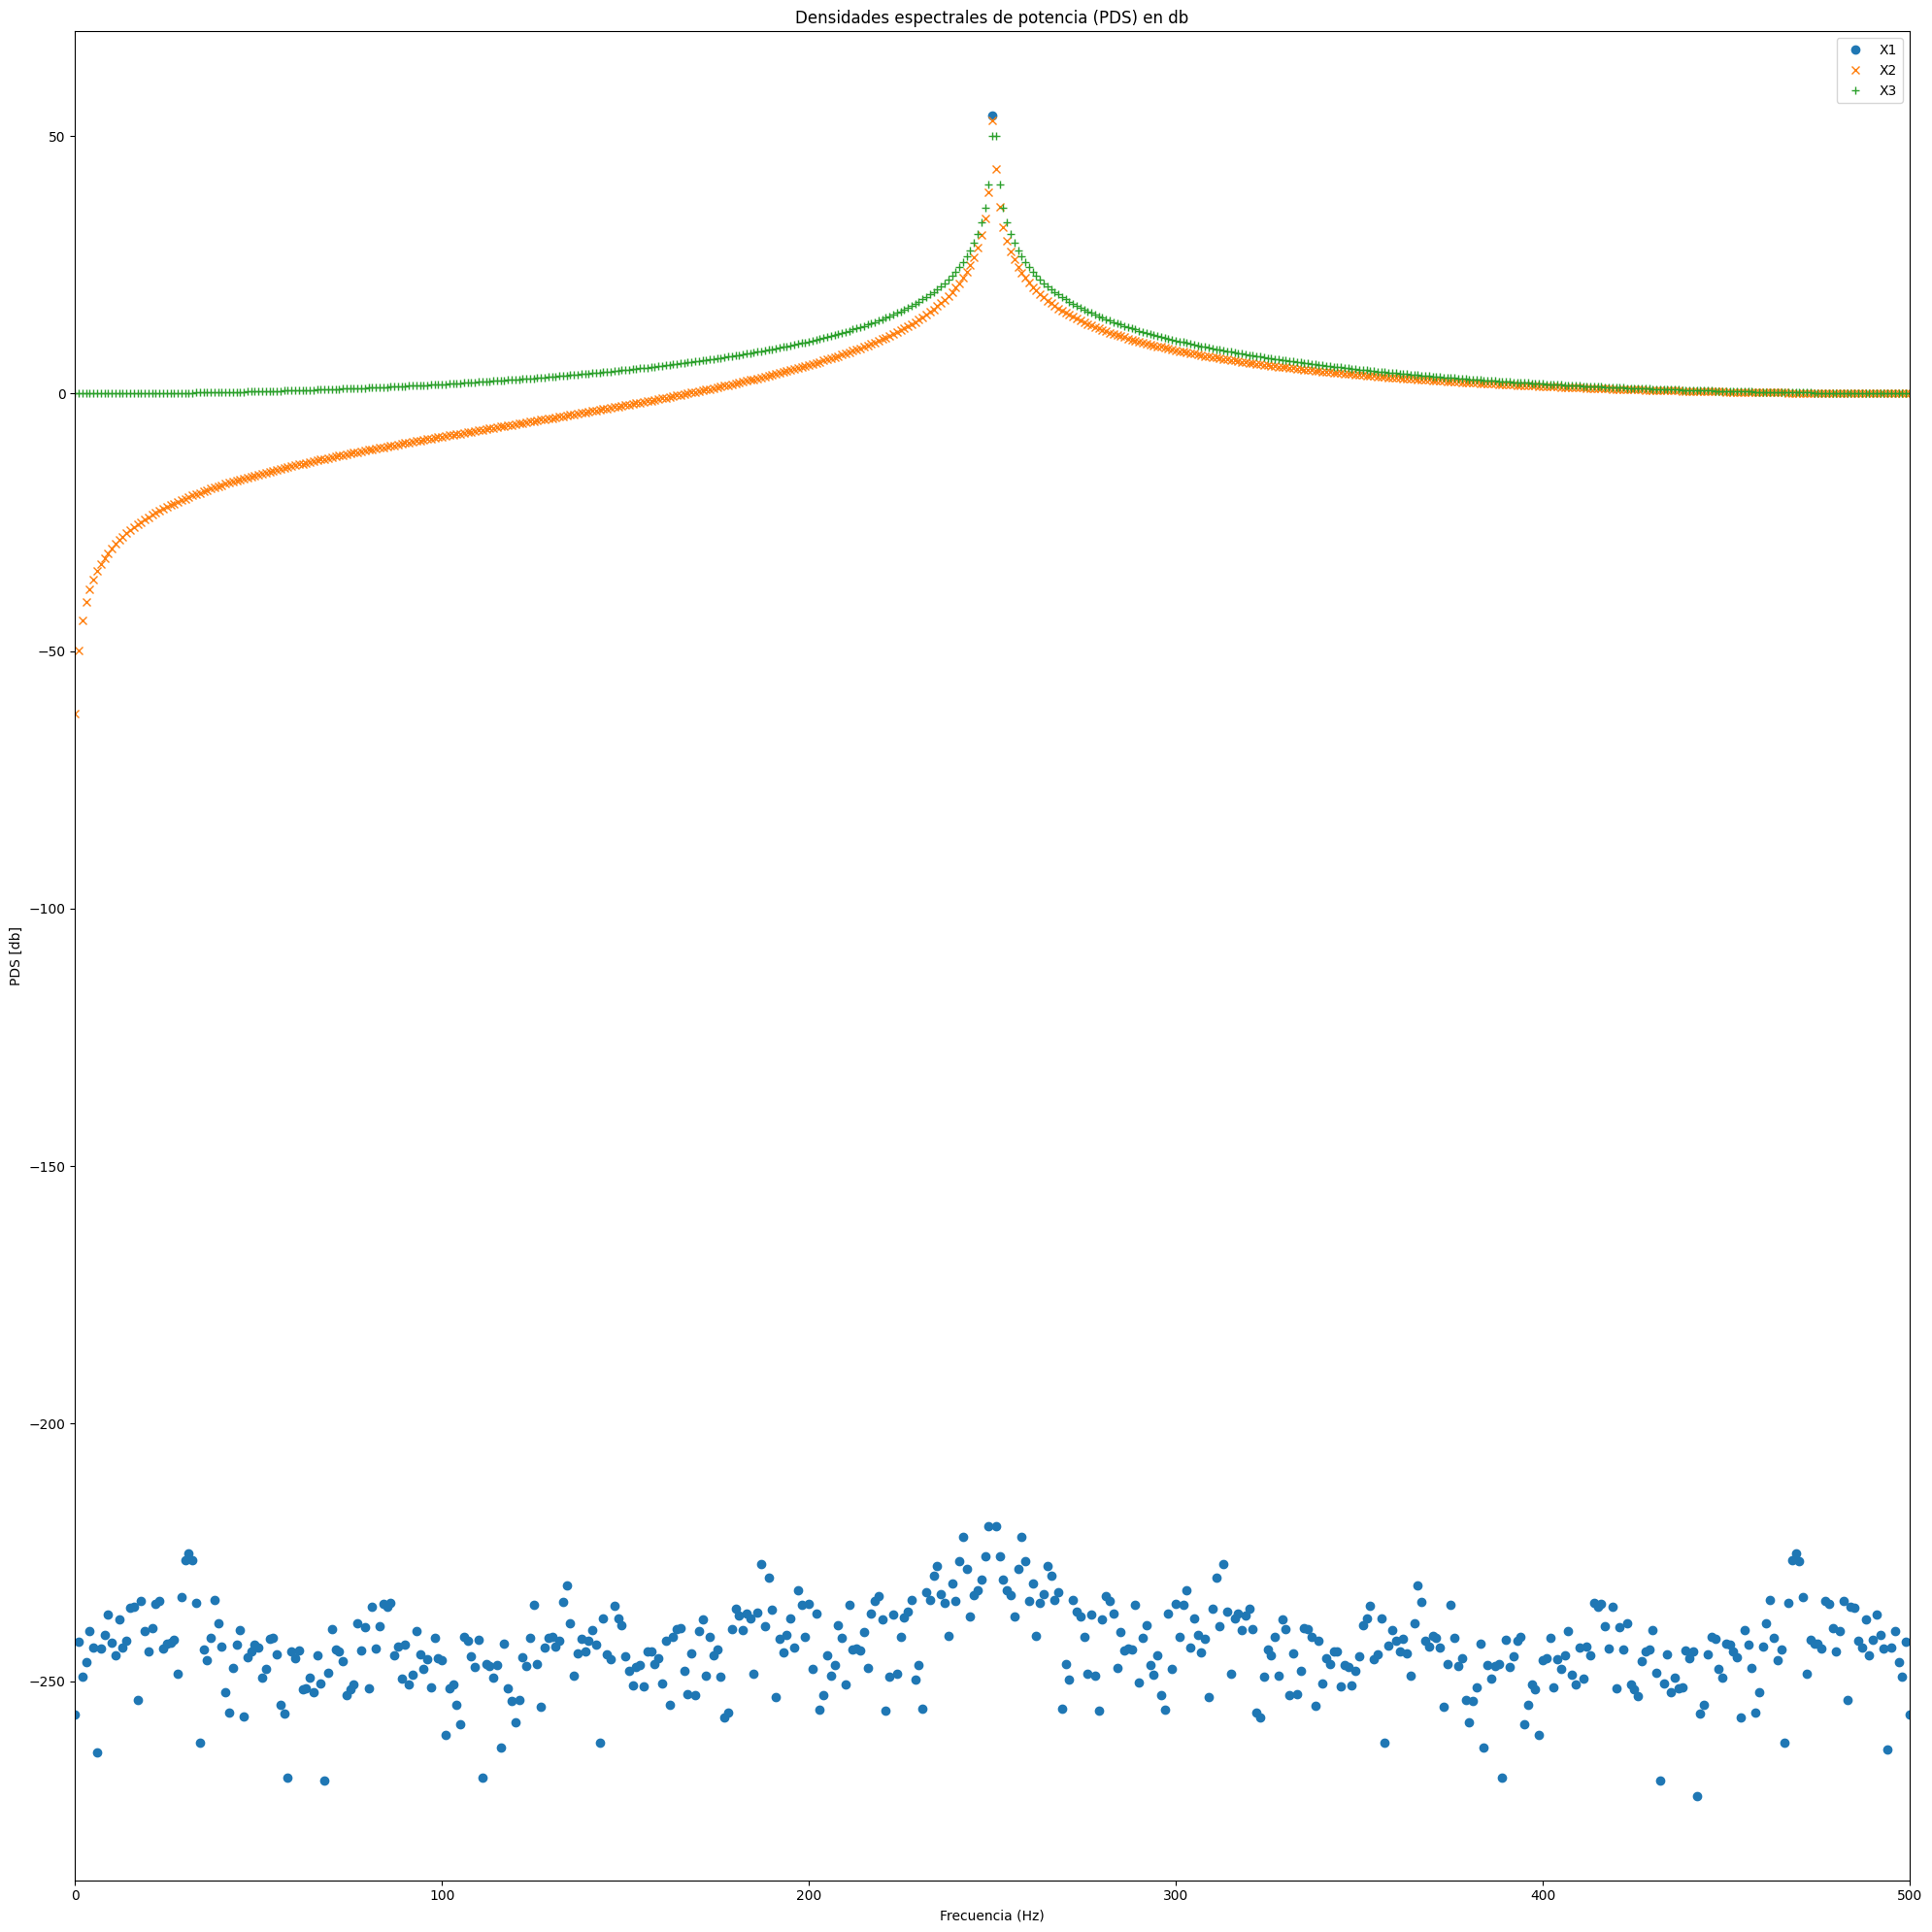

In [2]:
""" ------------------------------- EJERCICIO a ------------------------------- """

# DEFINO LAS VARIABLES
N = 1000
fs = N
df = fs/N # Resolucion temporal

# CALCULOS
# Las x en minuscula es porque estan en el espectro del tiempo
k0 = N / 4
t1,x1 = mi_funcion_sen(frecuencia = k0 * df, nn = N, fs = fs)

k0 = N / 4 + 0.25
t2,x2 = mi_funcion_sen(frecuencia = k0 * df, nn = N, fs = fs)

k0 = N / 4 + 0.5
t3,x3 = mi_funcion_sen(frecuencia = k0 * df, nn = N, fs = fs)

# CALCULO LA DFFT
# Las X en mayuscula son en el espectro de frecuencias, transformadas
X1 = fft(x1)
X2 = fft(x2)
X3 = fft(x3)

PDS1 = np.abs(X1)**2
PDS2 = np.abs(X2)**2
PDS3 = np.abs(X3)**2

# GRAFICOS EN db
ff = np.arange(N) * df # Es un arange de N que necesito para graficar

fig, axes = plt.subplots(1, 1, figsize=(20, 20))
plt.title("Densidades espectrales de potencia (PDS) en db")

# Grafico X1 en db
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PDS [db]')
plt.xlim([0, fs/2]) # En este caso fs = N, pero pongo fs para saber que va eso y no va siempre N
plt.plot(ff, np.log10(PDS1) * 10, 'o', label = 'X1') # En este caso es un db de tension
plt.legend()
 
# Grafico X2
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PDS [db]')
plt.xlim([0, fs/2]) # Una tuppla
plt.plot(ff, np.log10(PDS2) * 10, 'x', label = 'X2')
plt.legend()

# Grafico X3
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PDS [db]')
plt.xlim([0, fs/2]) # Una tuppla, por eso los corchetes, puede ser tambien entre parentesis 
plt.plot(ff, np.log10(PDS3) * 10, '+', label = 'X3')
plt.legend()

plt.tight_layout()
plt.show()

Se buscó comprender el efecto de la desintonía, agregada a cada senoidal respecto a $\Delta f$, en el espectro visualizado.

b) <font color=red><u> **Verificación de la potencia unitaria</u><font>**

En esta parte, se normalizó cada senoidal para que su potencia fuera unitaria ($\text{varianza} = 1$). Esto se verificó tanto en el dominio temporal como en el frecuencial. 

- En el tiempo se calculó la varianza de cada señal, obteniendo valores cercanos a 1 (diferencias atribuibles a redondeo numércio).
- En frecuencia, se corroboró que se cumple la identidad de parseval: la energía en el dominio temporal coincide con la suma de la energía en los coeficientes de la DFT.

In [3]:
""" ------------------------------- EJERCICIO b ------------------------------- """ 

# Normalizo mi funcion senoidal
t1, x1 = mi_funcion_sen(frecuencia = (N/4) * df, nn = N, amplitud = np.sqrt(2), fs = fs) # Sinusoidal con varianza unitaria ==> amp = raiz de 2

# Calculo la varianza
varianza_x1 = np.var(x1)

# Caluclo la FFT
X1 = fft(x1)

modulo_X1 = np.abs(X1)**2
# Parseval --> ambas energias tienen que ser iguales
E_t1 = np.sum(np.abs(x1)**2) # Energia en el tiempo
E_f1 = (1/N) * np.sum(modulo_X1) # Energia en frecuencia
diferencia1 = np.abs(E_t1 - E_f1) # Tiene que dar cero, o muy cercano a cero

print("------ Senoidal con frecuencia = N/4 ------")
print(f"Varianza = {varianza_x1:.3f}")
print("Parseval...")
print(f"Energía en tiempo: {E_t1:.3f}")
print(f"Energía en frecuencia: {E_f1:.3f}")
print(f"Diferencia: {diferencia1:.3f}")


# Normalizo la funcion
t2, x2 = mi_funcion_sen(frecuencia = (N/4 + 0.25) * df, nn = N, amplitud = np.sqrt(2), fs = fs) # Sinusoidal con varianza unitaria ==> amp = raiz de 2

# Calculo la varianza
varianza_x2 = np.var(x2)

# Caluclo la FFT
X2 = fft(x2)

modulo_X2 = np.abs(X2)**2
# Parseval --> ambas energias tienen que ser iguales
E_t2 = np.sum(np.abs(x2)**2) # Energia en el tiempo
E_f2 = (1/N) * np.sum(modulo_X2) # Energia en frecuencia
diferencia2 = np.abs(E_t2 - E_f2) # Tiene que dar cero, o muy cercano a cero


print("\n------ Senoidal con frecuencia = N/4 + 0.25 ------")
print(f"Varianza = {varianza_x2:.3f}")
print("Parseval...")
print(f"Energía en tiempo: {E_t2:.3f}")
print(f"Energía en frecuencia: {E_f2:.3f}")
print(f"Diferencia: {diferencia2:.3f}")


# Normalizo la funcion
t3, x3 = mi_funcion_sen(frecuencia = (N/4 + 0.5) * df, nn = N, amplitud = np.sqrt(2), fs = fs) # Sinusoidal con varianza unitaria ==> amp = raiz de 2

# Calculo la varianza
varianza_x3 = np.var(x3)

# Caluclo la FFT
X3 = fft(x3)

modulo_X3 = np.abs(X3)**2
# Parseval --> ambas energias tienen que ser iguales
E_t3 = np.sum(np.abs(x3)**2) # Energia en el tiempo
E_f3 = (1/N) * np.sum(modulo_X3) # Energia en frecuencia
diferencia3 = np.abs(E_t3 - E_f3) # Tiene que dar cero, o muy cercano a cero


print("\n------ Senoidal con frecuencia = N/4 + 0.5 ------")
print(f"Varianza = {varianza_x3:.3f}")
print("Parseval...")
print(f"Energía en tiempo: {E_t3:.3f}")
print(f"Energía en frecuencia: {E_f3:.3f}")
print(f"Diferencia: {diferencia3:.3f}")

------ Senoidal con frecuencia = N/4 ------
Varianza = 1.000
Parseval...
Energía en tiempo: 1000.000
Energía en frecuencia: 1000.000
Diferencia: 0.000

------ Senoidal con frecuencia = N/4 + 0.25 ------
Varianza = 0.999
Parseval...
Energía en tiempo: 999.000
Energía en frecuencia: 999.000
Diferencia: 0.000

------ Senoidal con frecuencia = N/4 + 0.5 ------
Varianza = 1.000
Parseval...
Energía en tiempo: 1000.000
Energía en frecuencia: 1000.000
Diferencia: 0.000


Se buscó verificar la potencia unitaria y explicar por qué dos senoidales con frecuencias muy cercanas pueden producir espectros tan distintos.

c) <font color=red><u> **Efecto del *zero padding*</u><font>**

Para finalizar este trabajo se aplicó la técnica de *zero padding*, añadiendo $9N$ ceros al final de cada señal antes de calcular la FFT. 

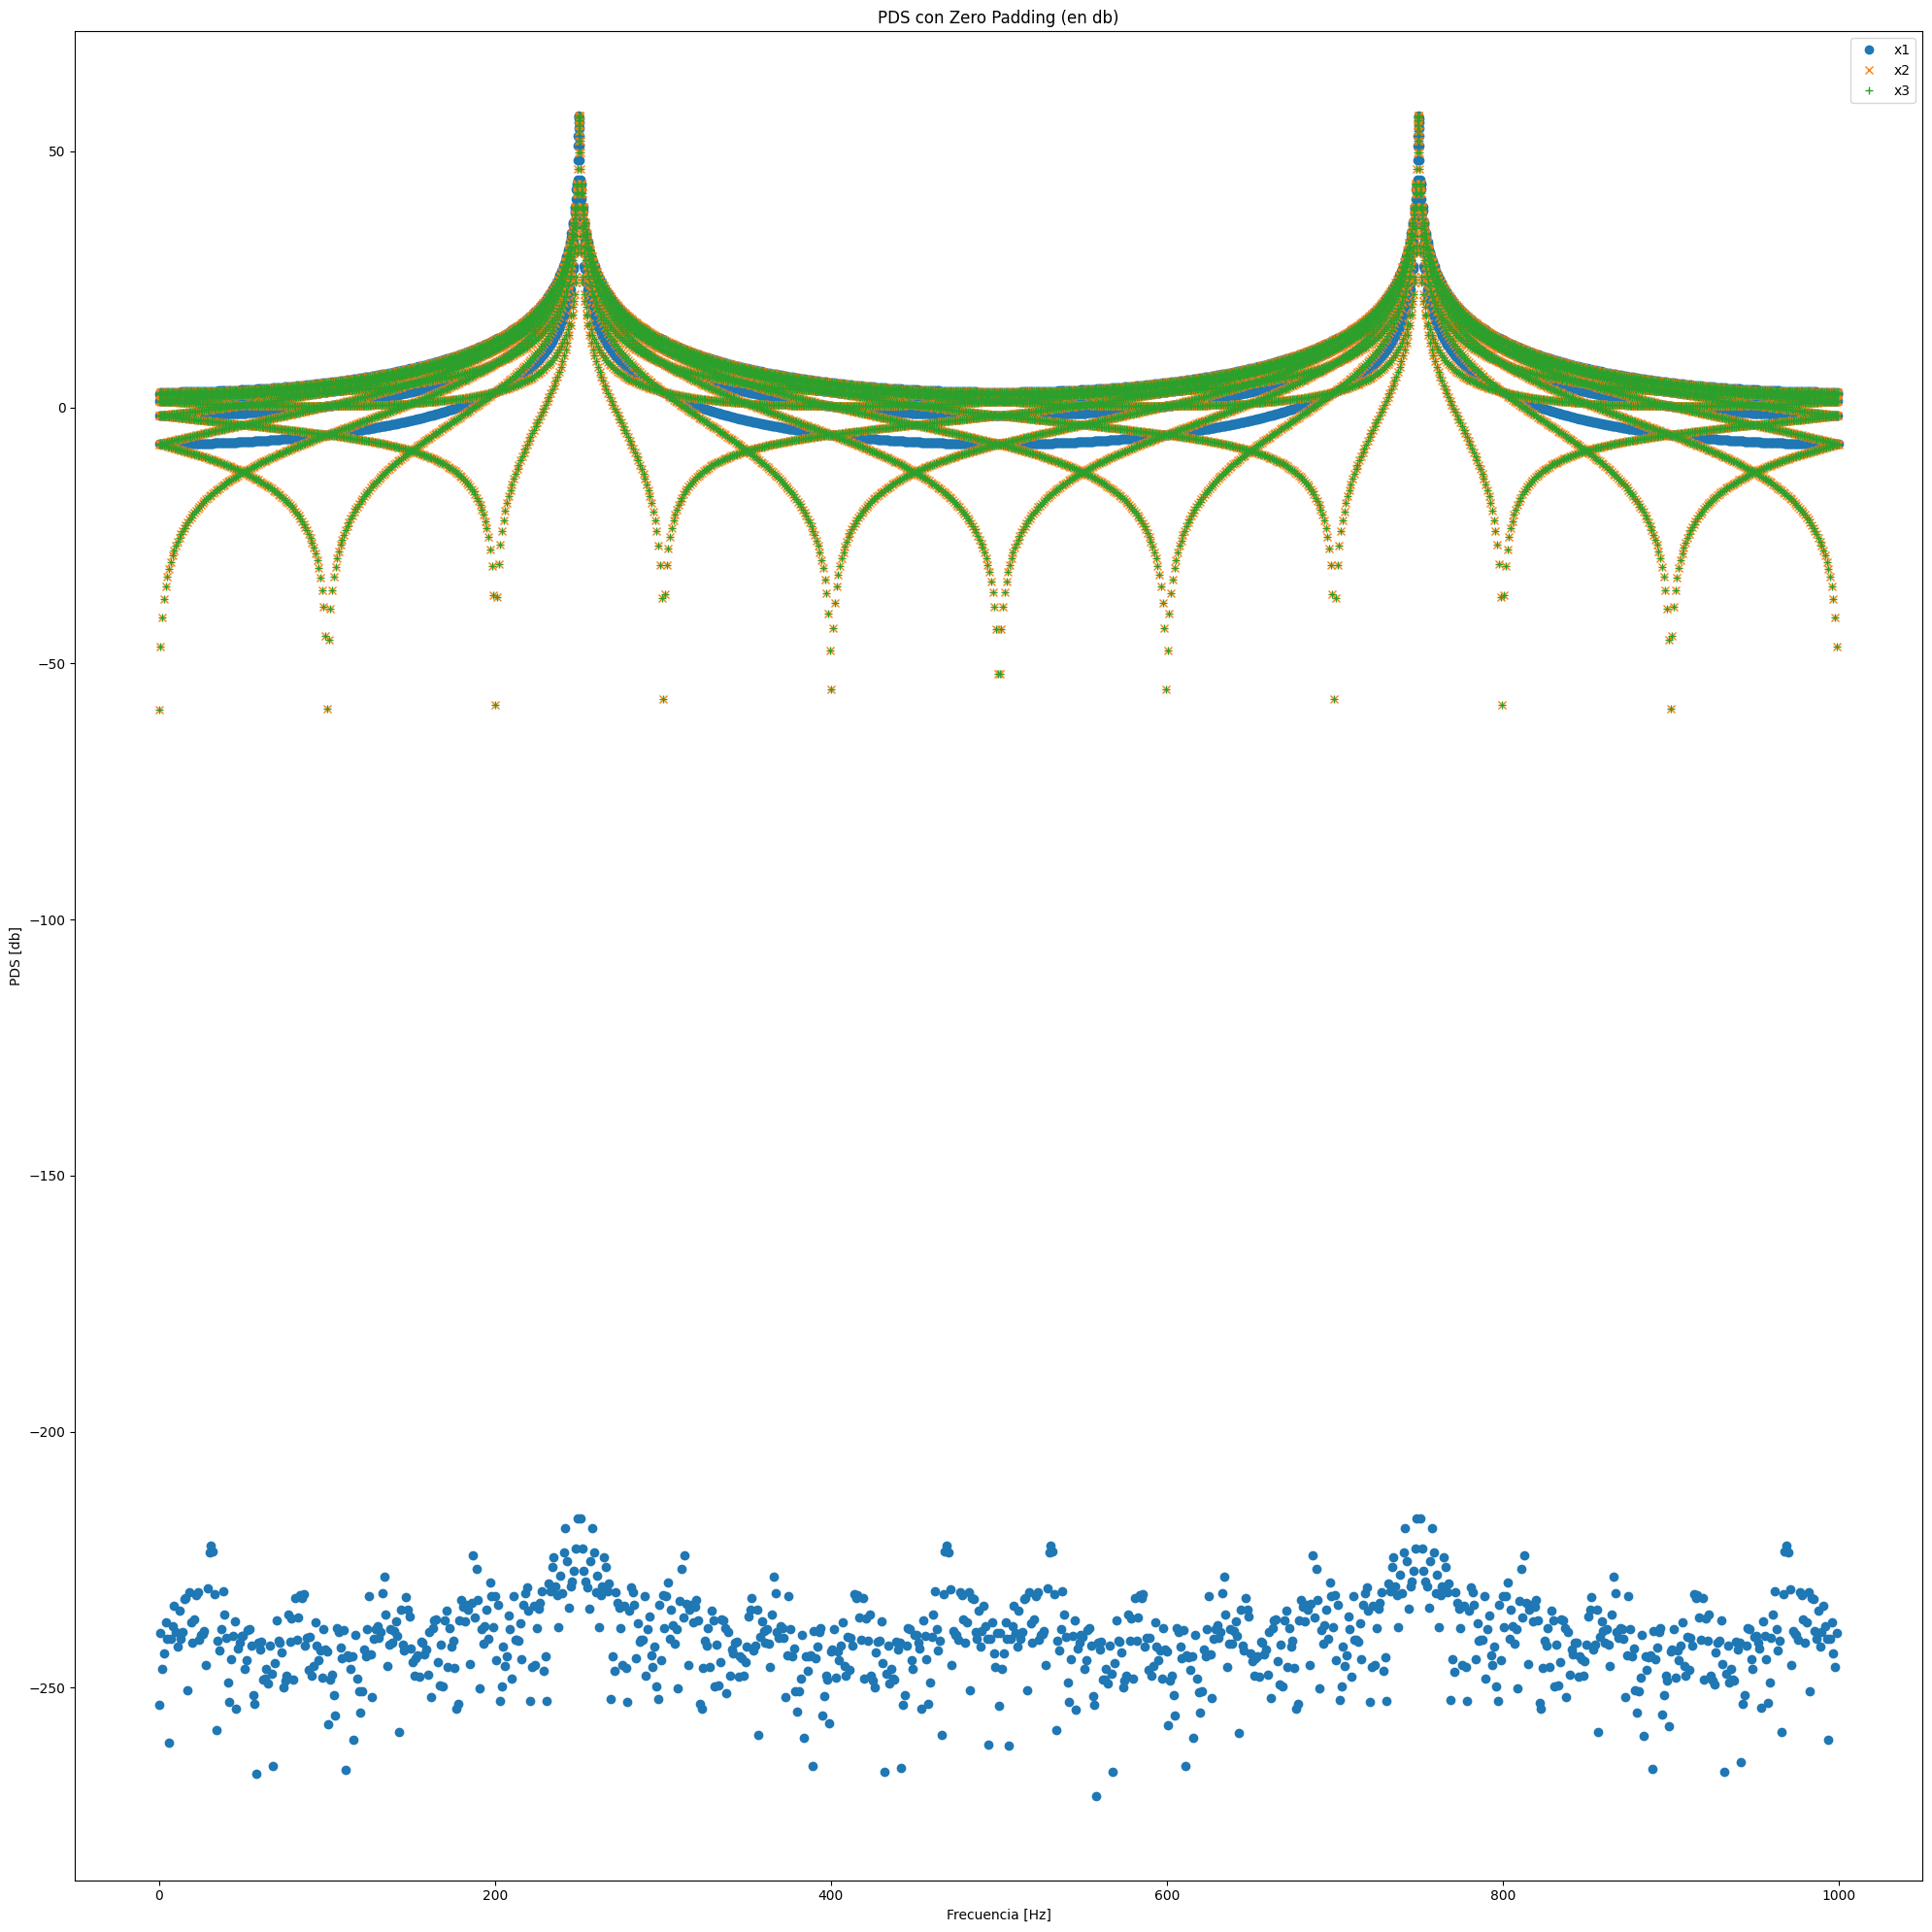

In [4]:
""" ------------------------------- EJERCICIO c ------------------------------- """

zp = np.zeros(9 * N)

x1p = np.concatenate((x1, zp))
x2p = np.concatenate((x2, zp))
x3p = np.concatenate((x3, zp))

# Calculo la FFT
X1p = fft(x1p)
X2p = fft(x2p)
X3p = fft(x3p)

# Ejes de frecuencia
Npadding = len(x1p)
df_padding = fs / Npadding
ff_padding = np.arange(Npadding) * df_padding

# Grafico en db
fig, axes = plt.subplots(1, 1, figsize=(20, 20))
plt.title("PDS con Zero Padding (en db)")

plt.plot(ff_padding, 10 * np.log10(np.abs(X1p)**2), 'o', label = 'x1')
plt.plot(ff_padding, 10 * np.log10(np.abs(X2p)**2), 'x', label = 'x2')
plt.plot(ff_padding, 10 * np.log10(np.abs(X2p)**2), '+', label = 'x3')

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PDS [db]")
plt.legend()
plt.tight_layout()
plt.show()


Esto se hizo con el objetivo de mejorar la visualización del espectro sin modificar la información frecuencial real de la señal. 

# <u>**Conclusión**</u>

a) <font color=red><u>**Efecto de la desintonía en el espectro**</u><font>

Cuando la frecuencia es exactamente un múltiplo de $\Delta f$ (como en el caso de $f_0 = \frac{N}{4}$), toda la energía de la señal se concentra en un único bin de la *DFT*, generando un pico muy definido.

Al desintonar ligeramente la frecuencia (como en el caso de $f_0 = \frac{N}{4} + 0.25$ y $f_0 = \frac{N}{4} + 0.5$), la energía se distribuye entre varios bins, el pico se ensancha y pierde definición. Este fenómeno ocurre porque la frecuencia ya no coincide exactamente con un bin de la *DFT*, lo que genera **fugas espectrales (*leakage*)**.

En consecuencia, incluso una mínima desintonía respecto a $\Delta f$ genera un cambio significativo en el espectro, pasando de un pico perfecto a un espectro más ancho y difuso.

El espectro obtenido mediante la *DFT* es extremadamente sensible a pequeñas desintonías respecto a la resolución frecuencial $\Delta f$.

b) <font color=red><u>**Potencia unitaria y distribución espectral**</u><font>

Todas las señales poseen la misma energía total (potencia normalizada o varianza unitaria), lo cual se verifica tanto en el dominio del tiempo como en el de la frecuencia mediante la *identidad de Parseval*. 

No obstante, la distribución de esa energía en el espectro cambia drásticamente: 
- La senoidal sintonizada ($f_0 = \frac{N}{4}$) concentra toda la energía en un solo bin, resultando en un *espectro "filoso"*.
- Las senoidales desintonizadas ($f_0 = \frac{N}{4} + 0.25$ y $f_0 = \frac{N}{4} + 0.5$) dispersan la energía entre varios bins, generando espectros más *"anchos"* y menos definidos.

Por lo tanto, el **leakage espectral** explica por qué dos senoidales con frecuencias muy cercanas pueden producir espectros tan distintos, porque lo que cambia no es la energía de la señal, sino cómo la *DFT* la distribuye entre sus bins.

c) <font color=red><u>**Efecto del zero padding**</u><font>

El *zero padding* no modifica la energía ni la forma de la señal original, pero incrementa la cantidad de puntos en el espectro, actuando como una interpolación de la *DFT*. Esto permite una mejor visualización: los picos se ven más definidos, especialmente en las señales desintonizadas, y es posible distinguir con mayor detalle los efectos del desparramo espectral.

En otras palabras, el *zero padding* aumenta la densidad de puntos en el espectro, haciendo que los picos se visualicen con mayor detalle, pero no incrementa la capacidad de la *DFT* para distinguir frecuencias separadas por menos que la resolución espectral $\Delta f = \frac{f_s}{N}$.